In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_original = pd.read_csv("datatran/datatran_2023_2024_2025.csv")
df = df_original.copy()

df['km'] = df['km'].str.replace(',', '.', regex=False) # Trocando formatação decimal para evitar perda de dados
df['km'] = pd.to_numeric(df['km'], errors='coerce')

capitais_brasil = [
    "rio branco",
    "maceio",
    "macapa",
    "manaus",
    "salvador",
    "fortaleza",
    "brasilia",
    "vitoria",
    "goiania",
    "são luis",
    "cuiaba",
    "campo grande",
    "belo horizonte",
    "belem",
    "joão pessoa",
    "curitiba",
    "recife",
    "teresina",
    "rio de janeiro",
    "natal",
    "porto alegre",
    "porto velho",
    "boa vista",
    "florianopolis",
    "são paulo",
    "aracaju",
    "palmas"
]

def normalizar(texto):
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    return texto

def municipio_to_capital(municipio):
    municipio = normalizar(municipio)

    if municipio in capitais_brasil:
        return 1
    else:
        return 0

df['capital'] = df['municipio'].apply(municipio_to_capital)

def classificar_macro_causa(causa):
    if pd.isna(causa):
        return "Outros"
    
    causa = causa.lower()
    
    # --- PEDRESTRE ---
    if "pedestre" in causa:
        return "Pedestre"
    
    # --- AMBIENTE ---
    if any(palavra in causa for palavra in [
        "chuva", "neblina", "fumaça", 
        "acumulo de água", "acumulo de óleo"
    ]):
        return "Ambiente"
    
    # --- MECÂNICA ---
    if any(palavra in causa for palavra in [
        "falhas mecânicas", "freio", "suspensão",
        "pneu", "faróis"
    ]):
        return "Mecânica"
    
    # --- VIA ---
    if any(palavra in causa for palavra in [
        "pista", "curva", "declive", "ondulação",
        "acostamento", "sinalização", "via",
        "obras", "drenagem", "desvio",
        "faixa", "acesso irregular",
        "semáforo com defeito",
        "elemento de contenção",
        "obstrução"
    ]):
        return "Via"
    
    # --- CONDUTOR ---
    if any(palavra in causa for palavra in [
        "condutor", "velocidade", "ultrapassagem",
        "manobra", "transitar", "conversão",
        "frear", "racha", "álcool",
        "reação", "mal súbito",
        "distância", "desrespeitou"
    ]):
        return "Condutor"
    
    return "Outros"

df["macro_causa"] = df["causa_acidente"].apply(classificar_macro_causa)

def mapa_clima(condicao):
    if pd.isna(condicao):
        return "Desconhecido"
    condicao = condicao.strip().lower()
    if condicao in ["céu claro", "sol", "vento"]:
        return "Normal"

    elif condicao in ["chuva", "garoa/chuvisco", "granizo", "neve", "nublado", "nevoeiro/neblina"]:
        return "Adversa"
    
    else:
        return "Desconhecido"
    
df["meteorologia"] = df["condicao_metereologica"].apply(mapa_clima)

def mapa_macro_tipo(tipo):
    if pd.isna(tipo):
        return "Outros"
    
    tipo = tipo.lower()
    
    # --- COLISÕES ENTRE VEÍCULOS ---
    if any(palavra in tipo for palavra in [
        "colisão frontal",
        "colisão traseira",
        "colisão transversal",
        "colisão lateral mesmo sentido",
        "colisão lateral sentido oposto",
        "engavetamento"
    ]):
        return "Colisão entre veículos"
    
    # --- COLISÃO COM OBJETO ---
    if any(palavra in tipo for palavra in [
        "colisão com objeto",
        "derramamento de carga"
    ]):
        return "Colisão com objeto"
    
    # --- PERDA DE CONTROLE / SAÍDA ---
    if any(palavra in tipo for palavra in [
        "saída de leito",
        "capotamento",
        "tombamento"
    ]):
        return "Perda de controle / saída de pista"
    
    # --- ATROPELAMENTO ---
    if "atropelamento" in tipo:
        return "Atropelamento"
    
    # --- SINISTRO INDIVIDUAL ---
    if any(palavra in tipo for palavra in [
        "queda de ocupante",
        "sinistro pessoal"
    ]):
        return "Sinistro individual"
    
    # --- OUTROS ---
    if any(palavra in tipo for palavra in [
        "incêndio",
        "eventos atípicos"
    ]):
        return "Outros"
    
    return "Outros"

df['macro_tipo'] = df['tipo_acidente'].apply(mapa_macro_tipo)

def mapa_fase_dia(fase):

    fase = fase.strip().lower()
    if fase in ["amanhecer", "pleno dia"]:
        return 1
    elif fase in ["plena noite", "anoitecer"]:
        return 0
    
df['dia'] = df['fase_dia'].apply(mapa_fase_dia)

def mapa_dia_semana(dia):

    dia = dia.strip().lower()
    if dia in ["segunda-feira", "terça-feira", "quarta-feira", "quinta-feira", "sexta-feira"]:
        return 1
    elif dia in ["sábado", "domingo"]:
        return 0

    
df['dia_util'] = df['dia_semana'].apply(mapa_dia_semana)

def rodovia_federal(br):
    if br != 0:
        return 1
    else:
        return 0

df['rodovia_federal'] = df['br'].apply(rodovia_federal)

colunas_remover = [
    'id',
    'data_inversa',
    'horario',
    'classificacao_acidente',
    'condicao_metereologica',
    'sentido_via',
    'tracado_via',
    'uso_solo',
    'pessoas',
    'feridos_leves',
    'feridos_graves',
    'ilesos',
    'ignorados',
    'veiculos',
    'latitude',
    'longitude',
    'regional',
    'delegacia',
    'uop',
    'municipio',
    'uf',
    'br',
    'causa_acidente',
    'tipo_acidente',
    'fase_dia',
    'dia_semana',
    'km'
]

df = df.drop(columns=colunas_remover)

df_sample = df.sample(20000, random_state=42)
df_sample

categoricas = [
    'macro_causa',
    'macro_tipo',
    'tipo_pista',
    'meteorologia'
]

df_encoded = pd.get_dummies(df_sample, columns=categoricas, drop_first=False)
df_encoded

# -------------------------- LOG --------------------------
df_encoded['mortos'] = np.log1p(df_encoded['mortos'])
df_encoded['feridos'] = np.log1p(df_encoded['feridos'])
# -------------------------- LOG --------------------------

cols_continuas = ['mortos', 'feridos']

scaler = StandardScaler()
df_encoded[cols_continuas] = scaler.fit_transform(df_encoded[cols_continuas])

df_scaled = df_encoded

df_scaled

C:\Users\igor.IGOR-DESKTOP\AppData\Local\Temp\ipykernel_21224\1859353851.py:8: DtypeWarning: Columns (0: latitude, 1: longitude) have mixed types. Specify dtype option on import or set low_memory=False.
  df_original = pd.read_csv("datatran/datatran_2023_2024_2025.csv")


,mortos,feridos,capital,dia,dia_util,rodovia_federal,macro_causa_Ambiente,macro_causa_Condutor,macro_causa_Mecânica,macro_causa_Outros,...,macro_tipo_Colisão entre veículos,macro_tipo_Outros,macro_tipo_Perda de controle / saída de pista,macro_tipo_Sinistro individual,tipo_pista_Dupla,tipo_pista_Múltipla,tipo_pista_Simples,meteorologia_Adversa,meteorologia_Desconhecido,meteorologia_Normal
51217,-0.266755,0.041425,0,1,0,1,False,True,False,False,...,True,False,False,False,False,False,True,False,False,True
41702,3.175706,-1.601172,0,0,0,1,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
203655,-0.266755,0.041425,0,1,0,1,False,True,False,False,...,False,False,True,False,True,False,False,True,False,False
196603,-0.266755,0.041425,0,1,1,1,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
147195,-0.266755,1.002282,0,1,1,1,False,False,False,False,...,True,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1684,-0.266755,0.041425,0,0,0,1,False,True,False,False,...,True,False,False,False,True,False,False,True,False,False
67679,-0.266755,2.644879,0,0,1,1,False,False,False,True,...,True,False,False,False,False,False,True,False,False,True
170271,-0.266755,0.041425,0,0,1,1,False,True,False,False,...,True,False,False,False,False,False,True,True,False,False
143555,-0.266755,0.041425,0,1,1,1,False,False,False,False,...,True,False,False,False,True,False,False,False,False,True


In [27]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import pandas as pd

In [18]:
# -------------------------------------------------------
# ABORDAGEM 1 — Com mortos e feridos (severidade)
# -------------------------------------------------------
pca_1 = PCA(n_components=10, random_state=42)
X_pca_1 = pca_1.fit_transform(df_scaled)

model_1 = AgglomerativeClustering(n_clusters=5, linkage='complete')
labels_1 = model_1.fit_predict(X_pca_1)

In [19]:
# -------------------------------------------------------
# ABORDAGEM 2 — Sem mortos e feridos (comportamental)
# -------------------------------------------------------
colunas_remover_sev = ['mortos', 'feridos']
df_comportamental = df_scaled.drop(columns=colunas_remover_sev)

pca_2 = PCA(n_components=10, random_state=42)
X_pca_2 = pca_2.fit_transform(df_comportamental)

model_2 = AgglomerativeClustering(n_clusters=5, linkage='complete')
labels_2 = model_2.fit_predict(X_pca_2)

In [20]:
# -------------------------------------------------------
# T-SNE — Redução para 2D (apenas para visualização)
# -------------------------------------------------------
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_2d_1 = tsne.fit_transform(X_pca_1)
X_2d_2 = tsne.fit_transform(X_pca_2)

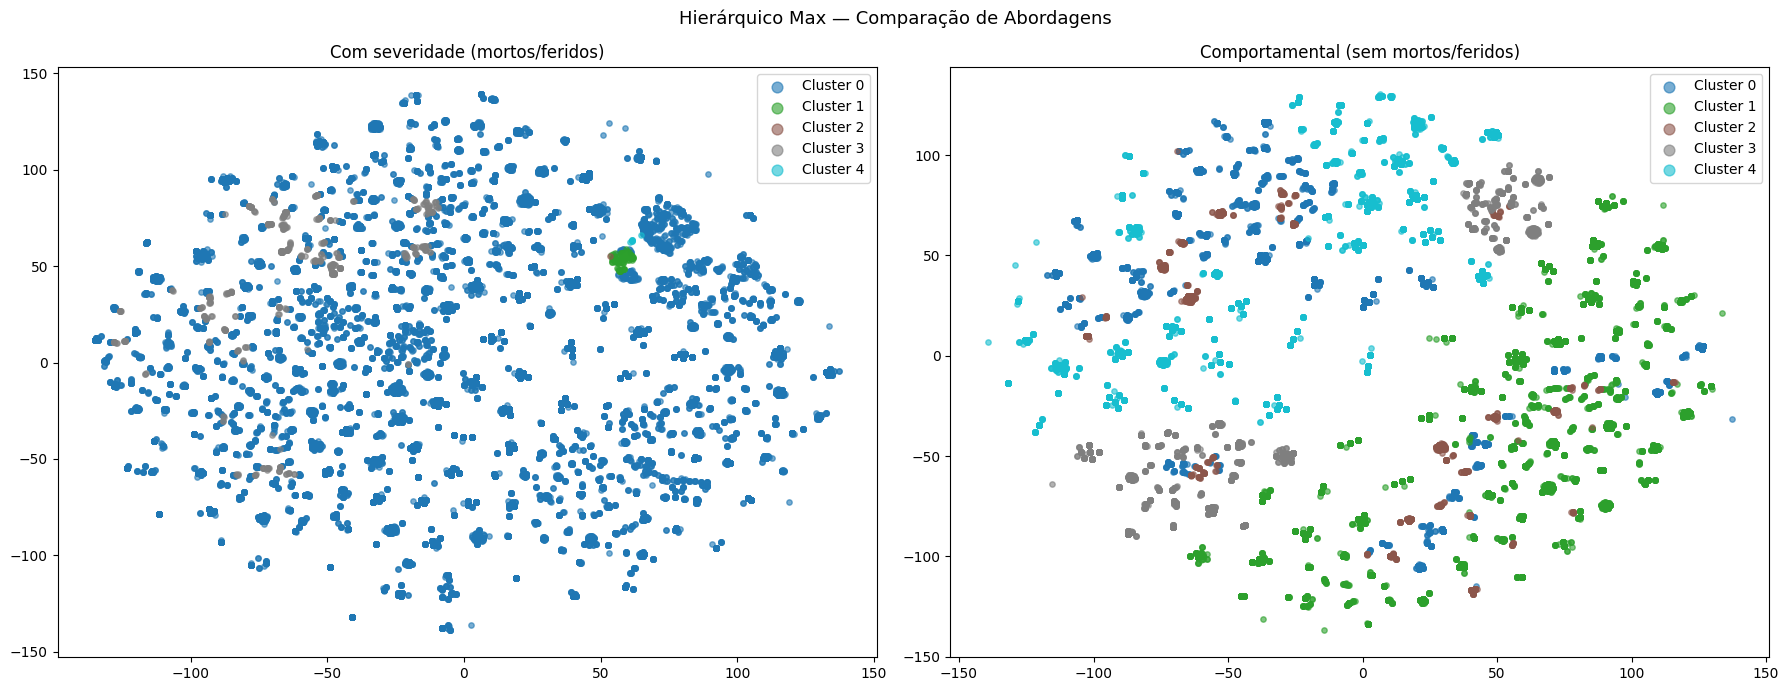

In [21]:
# -------------------------------------------------------
# VISUALIZAÇÃO — Comparação lado a lado
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
palette = plt.cm.tab10(np.linspace(0, 1, 5))

for ax, X_2d, labels, titulo in zip(
    axes,
    [X_2d_1, X_2d_2],
    [labels_1, labels_2],
    ['Com severidade (mortos/feridos)', 'Comportamental (sem mortos/feridos)']
):
    for i, k in enumerate(sorted(set(labels))):
        mask = labels == k
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[palette[i]], s=15, alpha=0.6, label=f'Cluster {k}')
    ax.set_title(titulo)
    ax.legend(markerscale=2)

plt.suptitle('Hierárquico Max — Comparação de Abordagens', fontsize=13)
plt.tight_layout()
plt.show()

In [29]:
# -------------------------------------------------------
# MÉTRICAS DE QUALIDADE DO CLUSTERING
# -------------------------------------------------------

resultados = []

for X, labels, nome in [
    (X_pca_1, labels_1, 'COM severidade'),
    (X_pca_2, labels_2, 'SEM severidade')
]:
    silhouette = silhouette_score(X, labels, sample_size=5000, random_state=42)
    davies     = davies_bouldin_score(X, labels)
    calinski   = calinski_harabasz_score(X, labels)

    resultados.append({
        'Abordagem':          nome,
        'Silhouette':       round(silhouette, 4),  # quanto maior melhor (max=1)
        'Davies-Bouldin':   round(davies, 4),      # quanto menor melhor (min=0)
        'Calinski-Harabasz':round(calinski, 2)     # quanto maior melhor
    })

df_metricas = pd.DataFrame(resultados).set_index('Abordagem')
print(df_metricas.to_string())

                Silhouette  Davies-Bouldin  Calinski-Harabasz
Abordagem                                                    
COM severidade      0.1971          0.8721             456.33
SEM severidade      0.1612          2.1954            1924.50


In [25]:
# -------------------------------------------------------
# PERFIL — Abordagem COM severidade (mortos/feridos)
# -------------------------------------------------------
colunas_perfil = ['mortos', 'feridos', 'capital', 'dia', 'dia_util', 'rodovia_federal']
colunas_categoricas = ['macro_causa', 'macro_tipo', 'meteorologia', 'tipo_pista']

df_result_1 = df_sample.copy()
df_result_1['cluster'] = labels_1

print("Tamanho dos clusters:")
for c in sorted(set(labels_1)):
    print(f"  Cluster {c}: {(labels_1==c).sum()} pontos ({(labels_1==c).mean():.1%})")

print("\nPerfil numérico:")
print(df_result_1.groupby('cluster')[colunas_perfil].mean().round(2).to_string())

print("\nPerfil categórico:")
print(df_result_1.groupby('cluster')[colunas_categoricas].agg(lambda x: x.mode()[0]).to_string())

Tamanho dos clusters:
  Cluster 0: 19433 pontos (97.2%)
  Cluster 1: 93 pontos (0.5%)
  Cluster 2: 1 pontos (0.0%)
  Cluster 3: 466 pontos (2.3%)
  Cluster 4: 7 pontos (0.0%)

Perfil numérico:
         mortos  feridos  capital   dia  dia_util  rodovia_federal
cluster                                                           
0          0.07     1.06     0.09  0.60      0.68              1.0
1          2.77     1.86     0.02  0.61      0.69              1.0
2         23.00     9.00     0.00  0.00      0.00              1.0
3          0.00     4.87     0.05  0.67      0.65              1.0
4          2.43    35.57     0.00  0.43      0.57              1.0

Perfil categórico:
        macro_causa              macro_tipo meteorologia tipo_pista
cluster                                                            
0          Condutor  Colisão entre veículos       Normal    Simples
1          Condutor  Colisão entre veículos       Normal    Simples
2          Condutor  Colisão entre veículos   

O clustering por severidade revelou uma limitação clara: 97.2% dos acidentes foram agrupados no Cluster 0, tornando a segmentação praticamente inútil para análise de padrões. Os clusters restantes representam casos extremos isolados — o Cluster 2 tem apenas 1 acidente com 23 mortos, e o Cluster 4 tem apenas 7 acidentes com média de 35 feridos. O perfil categórico é idêntico em todos os clusters (Condutor / Colisão entre veículos / Normal / Simples), confirmando que o algoritmo não encontrou padrões comportamentais — apenas separou outliers numéricos de mortos e feridos. Esta abordagem não é recomendada para análise exploratória.

In [26]:
# -------------------------------------------------------
# PERFIL — Abordagem SEM severidade (comportamental)
# -------------------------------------------------------
colunas_perfil = ['mortos', 'feridos', 'capital', 'dia', 'dia_util', 'rodovia_federal']
colunas_categoricas = ['macro_causa', 'macro_tipo', 'meteorologia', 'tipo_pista']

df_result_2 = df_sample.copy()
df_result_2['cluster'] = labels_2

print("Tamanho dos clusters:")
for c in sorted(set(labels_2)):
    print(f"  Cluster {c}: {(labels_2==c).sum()} pontos ({(labels_2==c).mean():.1%})")

print("\nPerfil numérico:")
print(df_result_2.groupby('cluster')[colunas_perfil].mean().round(2).to_string())

print("\nPerfil categórico:")
print(df_result_2.groupby('cluster')[colunas_categoricas].agg(lambda x: x.mode()[0]).to_string())

Tamanho dos clusters:
  Cluster 0: 3456 pontos (17.3%)
  Cluster 1: 7222 pontos (36.1%)
  Cluster 2: 1006 pontos (5.0%)
  Cluster 3: 1743 pontos (8.7%)
  Cluster 4: 6573 pontos (32.9%)

Perfil numérico:
         mortos  feridos  capital   dia  dia_util  rodovia_federal
cluster                                                           
0          0.06     0.98     0.04  0.58      0.62             0.99
1          0.04     1.13     0.12  0.63      0.69             1.00
2          0.23     0.96     0.16  0.38      0.71             1.00
3          0.03     1.10     0.18  0.62      0.75             1.00
4          0.14     1.35     0.03  0.60      0.67             1.00

Perfil categórico:
        macro_causa                          macro_tipo meteorologia tipo_pista
cluster                                                                        
0          Condutor  Perda de controle / saída de pista       Normal    Simples
1          Condutor              Colisão entre veículos       Normal

Cluster 0 — Saída de pista em rodovias rurais (17.3% / 3.456 acidentes)
Caracterizado por perda de controle e saída de pista em vias simples, longe de capitais (apenas 4% dos casos). Ocorre predominantemente durante o dia e em dias úteis. Provavelmente representa acidentes em rodovias rurais de mão única, onde a falta de infraestrutura e o cansaço do condutor são fatores de risco.

Cluster 1 — Colisões em rodovias de pista dupla (36.1% / 7.222 acidentes)
O maior grupo. Colisões entre veículos em pistas duplas, com maior proximidade de capitais (12%) e maior taxa de dias úteis (69%). Perfil típico de rodovias federais duplicadas de alto fluxo, onde o volume de tráfego aumenta o risco de colisões.

Cluster 2 — Atropelamentos noturnos (5.0% / 1.006 acidentes)
Único cluster com causa "Pedestre" e tipo "Atropelamento". Apresenta a maior taxa de mortos (0.23) e ocorre mais frequentemente à noite (dia=0.38, o menor de todos os clusters). Pista dupla sugere avenidas ou rodovias com travessia de pedestres. Perfil de alta periculosidade.

Cluster 3 — Colisões em vias expressas urbanas (8.7% / 1.743 acidentes)
Colisões em pistas múltiplas (3+ faixas), com maior proximidade de capitais (18%) e a maior taxa de dias úteis (75%). Perfil característico de rodovias expressas, perimetrais e marginais urbanas com alto fluxo no horário comercial.

Cluster 4 — Colisões em rodovias simples do interior (32.9% / 6.573 acidentes)
Segundo maior grupo. Colisões em pistas simples, com menor presença em capitais (3%) e maior média de feridos (1.35). Rodovias de mão dupla sem divisória física, onde ultrapassagens mal executadas e velocidade incompatível geram colisões frontais graves.